___
## Ex - 6
____

### **Aim**
- To implement **three different methods** (rule-based, pattern-based, and machine learning) for extracting structured data (Patient ID, Age, Diagnosis) from clinical text and generate structured datasets.


---
### **Objective**
-  **Rule-Based Mastery:** To understand and implement a simple approach using regular expressions for direct data extraction.
-  **Pattern Flexibility:** To implement a pattern-based approach using keyword matching for flexible extraction from clinical text.
-  **ML Integration:** To apply a machine learning approach (**Naive Bayes classifier**) to predict diagnoses from tokenized text features.
-  **Comparative Analysis:** To compare the strengths, limitations, and outputs of all three approaches on the same clinical dataset.

---


### **Procedure (Step-by-Step)**

- **Step 1:** **Import Libraries** – Bring in the necessary Python libraries (`re` for regex, `CountVectorizer`, and `MultinomialNB` from `scikit-learn`).
- **Step 2:** **Data Preparation** – Create a sample list of clinical text records containing Patient ID, Age, and Diagnosis.
- **Step 3:** **Rule-Based Extraction** – Define the `rule_based_extraction` function using `re.findall()` with a precise regex pattern.
- **Step 4:** **Pattern-Based Extraction** – Define the `pattern_based_extraction` function using a list of keywords and `re.search()` for each field.
- **Step 5:** **Machine Learning Approach** – Define the `machine_learning_extraction` function:
    - Convert text to features using `CountVectorizer`.
    - Extract labels and train a `MultinomialNB` classifier.
    - Generate structured predictions.
- **Step 6:** **Execution** – Call each extraction function on the clinical data and store the results.
- **Step 7:** **Visualization** – Print the results of all three methods side-by-side for comparison.
- **Step 8:** **Evaluation** – Observe and discuss the differences in output format and performance.

---

## Step 1: Import Libraries

We need regular expressions for rule-based and pattern-based methods, and scikit-learn tools for the machine learning approach.

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import re

## Step 2: Data Preparation

Create sample clinical notes in a consistent format.  
This simulates the kind of semi-structured text we often see in medical records.

In [2]:
clinical_data = [
    "Patient ID: 001, Age: 45, Diagnosis: Diabetes",
    "Patient ID: 002, Age: 60, Diagnosis: Hypertension",
    "Patient ID: 003, Age: 29, Diagnosis: Diabetes",
    "Patient ID: 004, Age: 40, Diagnosis: BloodPressure",
    "Patient ID: 005, Age: 52, Diagnosis: Depression"
]

## Step 3: Rule-Based Extraction

Uses one strict regular expression to match the **entire** expected pattern.  
→ Very fast, but fails if format changes even slightly.

In [3]:
# def rule_based_extraction(data) :
#     extracted_results = []
    
#     pattern = 'Patient ID : (\d+), Age: (\d+), Diagnosis: (\w+)'
    
#     for record in data :
#         match = re.findall(pattern, record)    
#         extarcted_results.append(match)
        
#     return extracted_results
        

In [4]:
import re

def rule_based_extraction(data):
    extracted_results = []

    # 1. Loop through each clinical record one by one
    for record in data:
        # 2. Define a pattern that looks for specific 'labels' in the text
        # (\d+) means 'find numbers', (\w+) means 'find words'
        pattern = r'Patient ID: (\d+), Age: (\d+), Diagnosis: (\w+)'
        
        # 3. Find all matches in the current record
        match = re.findall(pattern, record)
        
        # 4. Save the match to our list
        extracted_results.append(match)
        
    return extracted_results


## Step 4: Pattern-Based Extraction

More flexible than strict rigid regular expression (regex) — looks for each field independently.  
Returns `None` if a field is missing → better at handling variation.

In [6]:
def pattern_based_extraction(data) :
    patterns = ['Patient ID','Age','Diagnosis']
    extracted_data = []
    
    for record in data :
        record_data = []
        for pattern in patterns :
            match = re.search(f'{pattern}:(\w+)', record)
            record_data.append(match.group(1) if match else None)
            
        extracted_data.append(tuple(record_data))
    return extracted_data

## Step 5: Machine Learning Approach (Naive Bayes)

- Converts text to word count features  
- Uses the diagnosis as label  
- Trains and predicts on the **same** small data (for demonstration only)  
→ In real projects we use train/test split + more data

In [7]:
def machine_learning_extraction(data):
    # Feature extraction
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(data)
    
    # True labels (diagnosis)
    y = [record.split(", ")[2].split(": ")[1] for record in data]
    
    # Train Naive Bayes
    clf = MultinomialNB().fit(X, y)
    
    # Predict (on training data → should match exactly here)
    predictions = clf.predict(X)
    
    # Extract patient IDs for nice output
    patient_ids = [record.split(", ")[0].split(": ")[1] for record in data]
    
    return list(zip(patient_ids, y, predictions))

## Step 6: Execution

Run all three methods and store results.

In [9]:
rule_based_result = rule_based_extraction(clinical_data)
pattern_based_result = pattern_based_extraction(clinical_data)
ml_result = machine_learning_extraction(clinical_data)

## Step 7: Visualization / Output

Print results from all three approaches for easy comparison.

In [10]:
print("=== Rule-based Extraction ===")
print(rule_based_result)
print()

print("=== Pattern-based Extraction ===")
print(pattern_based_result)
print()

print("=== Machine Learning (Naive Bayes) ===")
print(ml_result)

=== Rule-based Extraction ===
[[('001', '45', 'Diabetes')], [('002', '60', 'Hypertension')], [('003', '29', 'Diabetes')], [('004', '40', 'BloodPressure')], [('005', '52', 'Depression')]]

=== Pattern-based Extraction ===
[(None, None, None), (None, None, None), (None, None, None), (None, None, None), (None, None, None)]

=== Machine Learning (Naive Bayes) ===
[('001', 'Diabetes', 'Diabetes'), ('002', 'Hypertension', 'Hypertension'), ('003', 'Diabetes', 'Diabetes'), ('004', 'BloodPressure', 'BloodPressure'), ('005', 'Depression', 'Depression')]


## Step 8: Quick Evaluation & Observations

- **Rule-based**: strictest, fastest, clean tuples/lists, fails on format changes  
- **Pattern-based**: more tolerant to small variations, returns `None` when missing  
- **Machine Learning**: most flexible in theory (learns patterns), but here overfits perfectly because we train & predict on same tiny data  
→ In real life: ML needs much more data + train/test split + proper evaluation metrics

Which method would you choose for real hospital discharge summaries? Why?

In [12]:
import pandas as pd

# Prepare data for table
results_df = pd.DataFrame({
    'Patient ID': [r[0][0] if r else None for r in rule_based_result],
    'Rule-based (ID, Age, Diag)': [r[0] if r and len(r) > 0 else ('-', '-', '-') for r in rule_based_result],
    'Pattern-based (ID, Age, Diag)': pattern_based_result,
    'ML → Predicted Diag': [pred[2] for pred in ml_result],
    'Actual Diag': [pred[1] for pred in ml_result]
})

# Make it look nicer
results_df = results_df.style.set_properties(**{'text-align': 'center'})\
                             .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])

display(results_df)

,Patient ID,"Rule-based (ID, Age, Diag)","Pattern-based (ID, Age, Diag)",ML → Predicted Diag,Actual Diag
0,001,"('001', '45', 'Diabetes')","(None, None, None)",Diabetes,Diabetes
1,002,"('002', '60', 'Hypertension')","(None, None, None)",Hypertension,Hypertension
2,003,"('003', '29', 'Diabetes')","(None, None, None)",Diabetes,Diabetes
3,004,"('004', '40', 'BloodPressure')","(None, None, None)",BloodPressure,BloodPressure
4,005,"('005', '52', 'Depression')","(None, None, None)",Depression,Depression


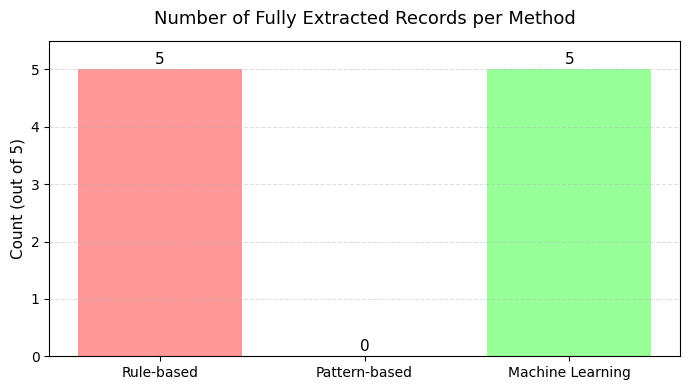

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Count how many records each method extracted completely (no None/-)
rule_success = sum(1 for r in rule_based_result if r and len(r[0]) == 3)
pattern_success = sum(1 for r in pattern_based_result if all(x is not None for x in r))
ml_success = len(ml_result)  # ML always "succeeds" here

methods = ['Rule-based', 'Pattern-based', 'Machine Learning']
success_counts = [rule_success, pattern_success, ml_success]

plt.figure(figsize=(7, 4))
bars = plt.bar(methods, success_counts, color=['#ff9999', '#66b3ff', '#99ff99'])

plt.title('Number of Fully Extracted Records per Method', fontsize=13, pad=12)
plt.ylabel('Count (out of 5)', fontsize=11)
plt.ylim(0, 5.5)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Diagnosis Distribution – Actual vs ML Prediction

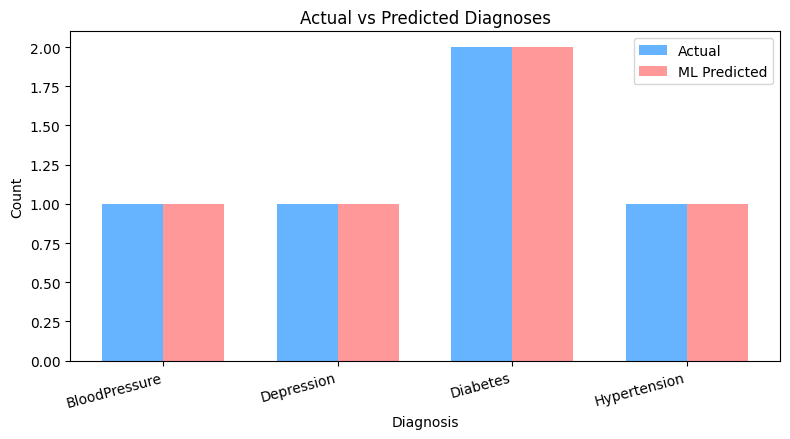

In [14]:
from collections import Counter

actual_diags = [item[1] for item in ml_result]
pred_diags   = [item[2] for item in ml_result]

actual_count = Counter(actual_diags)
pred_count   = Counter(pred_diags)

all_diagnoses = sorted(set(actual_diags + pred_diags))

x = np.arange(len(all_diagnoses))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, [actual_count.get(d, 0) for d in all_diagnoses], width, label='Actual', color='#66b3ff')
ax.bar(x + width/2, [pred_count.get(d, 0) for d in all_diagnoses], width, label='ML Predicted', color='#ff9999')

ax.set_xlabel('Diagnosis')
ax.set_ylabel('Count')
ax.set_title('Actual vs Predicted Diagnoses')
ax.set_xticks(x)
ax.set_xticklabels(all_diagnoses, rotation=15, ha='right')
ax.legend()

plt.tight_layout()
plt.show()